In [3]:
import pandas as pd
import numpy as np
print("E comerce Data Analysis Project started")

E comerce Data Analysis Project started


## E-commerce Data sales analysis
this project analysis an e-commerce dataset to understand sales performace,product demand,customer behavior using python and pandas


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
print("library loaded successfully")

library loaded successfully


In [12]:
import os
os.getcwd()

'c:\\project\\E commerce-analysis\\notebooks'

In [13]:
os.listdir()

['analysis.ipynb']

In [19]:
orders = pd.read_csv("../Data/archive/olist_orders_dataset.csv")
products = pd.read_csv("../Data/archive/olist_products_dataset.csv")
customers = pd.read_csv("../Data/archive/olist_customers_dataset.csv")

print("Data loaded successfully")


Data loaded successfully


In [25]:
orders.shape
orders.columns
orders.info()
print("this orders dataset contain 99441 rows and 8 column")

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB
this orders dataset contain 99441 rows and 8 column


In [27]:
orders.isnull().sum()
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [35]:
orders["order_purchase_timestamp"]= pd.to_datetime(orders["order_purchase_timestamp"])
orders["order_approved_at"]= pd.to_datetime(orders["order_approved_at"])
orders["order_delivered_carrier_date"]= pd.to_datetime(orders["order_delivered_carrier_date"])
orders["order_delivered_customer_date"]= pd.to_datetime(orders["order_delivered_customer_date"])
orders["order_estimated_delivery_date"]= pd.to_datetime(orders["order_estimated_delivery_date"])

print("data type change successfully")
orders.info()

data type change successfully
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


In [38]:
orders["order_month"] = orders["order_purchase_timestamp"].dt.to_period("M")
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02


In [42]:
order_per_month = orders.groupby("order_month").size()
order_per_month


order_month
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, dtype: int64

In [45]:
import matplotlib.pyplot as plt

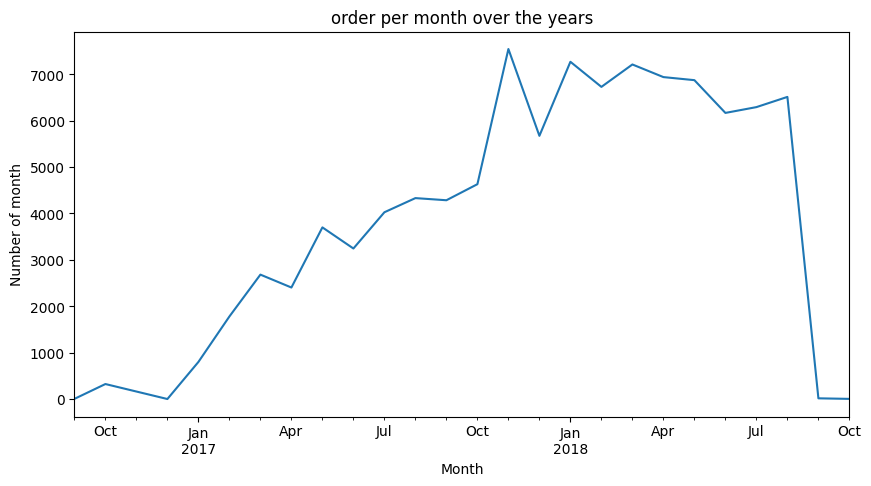

In [48]:
order_per_month.plot(figsize=(10,5))

plt.title("order per month over the years")
plt.xlabel("Month")
plt.ylabel("Number of month")

plt.show()

## Key Insight

The number of orders increased significantly from 2017 to 2018, showing strong growth in the e-commerce platform. However, a noticeable drop in orders occurs around October 2018. This decline may indicate seasonal changes, incomplete data for the month, or a temporary decrease in platform activity.

In [57]:
orders["order_purchase_timestamp"].max()

Timestamp('2018-10-17 17:30:18')

In [59]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
order_month                         0
dtype: int64

## Missing Values Analysis

Some delivery-related columns contain missing values. This is expected because orders that were canceled or unavailable were never delivered. Therefore, delivery timestamps are naturally missing for those orders.

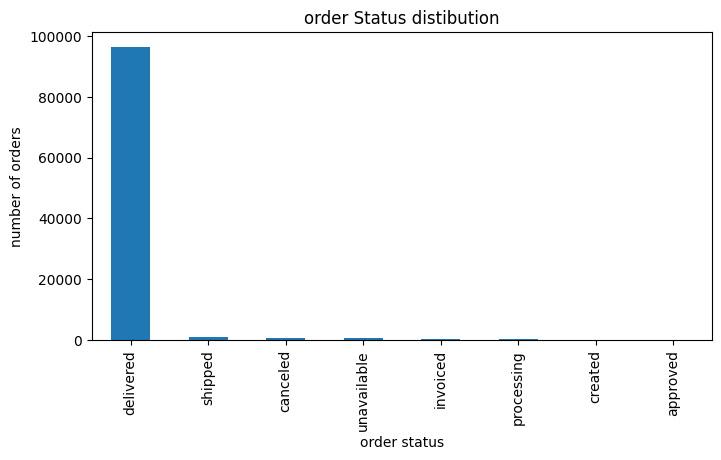

In [71]:
## order status analysis

status_count = orders["order_status"].value_counts()

status_count.plot(kind="bar",figsize=(8,4))
plt.title("order Status distibution")
plt.xlabel("order status")
plt.ylabel("number of orders")

plt.show()

## Order Status Insight

Most orders are successfully delivered, representing the vast majority of transactions. Only a small percentage of orders are canceled or unavailable, indicating generally reliable order fulfillment.

In [87]:
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])

In [89]:
orders["delivery_time"] = (
    orders["order_delivered_customer_date"] -
    orders["order_purchase_timestamp"]
)

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_month,delivery_time
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,8 days 10:28:40
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07,13 days 18:46:08
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08,9 days 09:27:40
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11,13 days 05:00:36
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02,2 days 20:58:23


In [90]:
orders["delivery_days"] = orders["delivery_time"].dt.days

In [92]:
orders[["delivery_time","delivery_days"]].head(10)

,delivery_time,delivery_days
0,8 days 10:28:40,8.0
1,13 days 18:46:08,13.0
2,9 days 09:27:40,9.0
3,13 days 05:00:36,13.0
4,2 days 20:58:23,2.0
5,16 days 13:00:50,16.0
6,NaT,NaN
7,9 days 23:45:21,9.0
8,9 days 19:39:01,9.0
9,18 days 05:19:28,18.0


In [95]:
orders["delivery_days"].describe()

count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

In [97]:
orders[orders["delivery_days"]==209]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_month,delivery_time,delivery_days
19590,ca07593549f1816d26a572e06dc1eab6,75683a92331068e2d281b11a7866ba44,delivered,2017-02-21 23:31:27,2017-02-23 02:35:15,2017-03-08 13:47:46,2017-09-19 14:36:39,2017-03-22,2017-02,209 days 15:05:12,209.0


### Outlier Observation

One order shows an extremely long delivery time of 209 days. 
This value is significantly higher than the typical delivery range (6–15 days) and may represent a logistics delay or a data recording issue.

## Order Items Dataset Analysis

In [100]:
order_items = pd.read_csv("../data/archive/olist_order_items_dataset.csv")
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [104]:
order_items.shape
order_items.columns
order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


In [106]:
order_items["shipping_limit_date"] = pd.to_datetime(order_items['shipping_limit_date'])
order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  str           
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  str           
 3   seller_id            112650 non-null  str           
 4   shipping_limit_date  112650 non-null  datetime64[us]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(3)
memory usage: 6.0 MB


In [107]:
order_items.describe()

,order_item_id,shipping_limit_date,price,freight_value
count,112650.000000,112650,112650.000000,112650.000000
mean,1.197834,2018-01-07 15:36:52.192685,120.653739,19.990320
min,1.000000,2016-09-19 00:15:34,0.850000,0.000000
25%,1.000000,2017-09-20 20:57:27.500000,39.900000,13.080000
50%,1.000000,2018-01-26 13:59:35,74.990000,16.260000
75%,1.000000,2018-05-10 14:34:00.750000,134.900000,21.150000
max,21.000000,2020-04-09 22:35:08,6735.000000,409.680000
std,0.705124,NaN,183.633928,15.806405


In [111]:
order_items.sort_values(by="price",ascending=False).head(10)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
3556,0812eb902a67711a1cb742b3cdaa65ae,1,489ae2aa008f021502940f251d4cce7f,e3b4998c7a498169dc7bce44e6bb6277,2017-02-16 20:37:36,6735.00,194.31
112233,fefacc66af859508bf1a7934eab1e97f,1,69c590f7ffc7bf8db97190b6cb6ed62e,80ceebb4ee9b31afb6c6a916a574a1e2,2018-08-02 04:05:13,6729.00,193.21
107841,f5136e38d1a14a4dbd87dff67da82701,1,1bdf5e6731585cf01aa8169c7028d6ad,ee27a8f15b1dded4d213a468ba4eb391,2017-06-15 02:45:17,6499.00,227.66
74336,a96610ab360d42a2e5335a3998b4718a,1,a6492cc69376c469ab6f61d8f44de961,59417c56835dd8e2e72f91f809cd4092,2017-04-18 13:25:18,4799.00,151.34
11249,199af31afc78c699f0dbf71fb178d4d4,1,c3ed642d592594bb648ff4a04cee2747,59417c56835dd8e2e72f91f809cd4092,2017-05-09 15:50:15,4690.00,74.34
62086,8dbc85d1447242f3b127dda390d56e19,1,259037a6a41845e455183f89c5035f18,c72de06d72748d1a0dfb2125be43ba63,2018-06-28 12:36:36,4590.00,91.78
29193,426a9742b533fc6fed17d1fd6d143d7e,1,a1beef8f3992dbd4cd8726796aa69c53,512d298ac2a96d1931b6bd30aa21f61d,2018-08-16 14:24:28,4399.87,113.45
45843,68101694e5c5dc7330c91e1bbc36214f,1,6cdf8fc1d741c76586d8b6b15e9eef30,ed4acab38528488b65a9a9c603ff024a,2018-04-05 08:27:27,4099.99,75.27
78310,b239ca7cd485940b31882363b52e6674,1,dd113cb02b2af9c8e5787e8f1f0722f6,821fb029fc6e495ca4f08a35d51e53a5,2018-08-02 08:15:14,4059.00,104.51
59137,86c4eab1571921a6a6e248ed312f5a5a,1,6902c1962dd19d540807d0ab8fade5c6,fa1c13f2614d7b5c4749cbc52fecda94,2017-03-23 20:08:04,3999.90,17.01


In [115]:
order_items["price"].sum()


np.float64(13591643.7)

In [116]:
order_items["freight_value"].sum()

np.float64(2251909.54)

In [121]:
order_items["total_value"] = order_items["price"]+order_items["freight_value"]
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,218.04


In [122]:
order_items["total_value"].sum()

np.float64(15843553.24)

## seller revenue analysis

In [129]:
seller_revenue = order_items.groupby("seller_id")["total_value"].sum()
seller_revenue.head()

seller_id
0015a82c2db000af6aaaf3ae2ecb0532     2748.06
001cca7ae9ae17fb1caed9dfb1094831    33934.17
001e6ad469a905060d959994f1b41e4f      267.94
002100f778ceb8431b7a1020ff7ab48f     2028.16
003554e2dce176b5555353e4f3555ac8      139.38
Name: total_value, dtype: float64

In [ ]:
# top seller

seller_revenue.sort_values(ascending=False).head(10)

seller_id
cf6f6bc4df3999b9c6440f124fb2f687    12.22
77128dec4bec4878c37ab7d6169d6f26    15.22
1fa2d3def6adfa70e58c276bb64fe5bb    15.90
4965a7002cca77301c82d3f91b82e1a9    16.36
702835e4b785b67a084280efca355756    18.56
ad14615bdd492b01b0d97922e87cb87f    19.21
3ac588cd562971392504a9e17130c40b    19.29
c1dde11f12d05c478f5de2d7319ad3b2    19.89
cc1f04647be106ba74e62b21f358af25    20.19
b5f0712d22a873b6797ab6cc65c3fcba    21.28
Name: total_value, dtype: float64

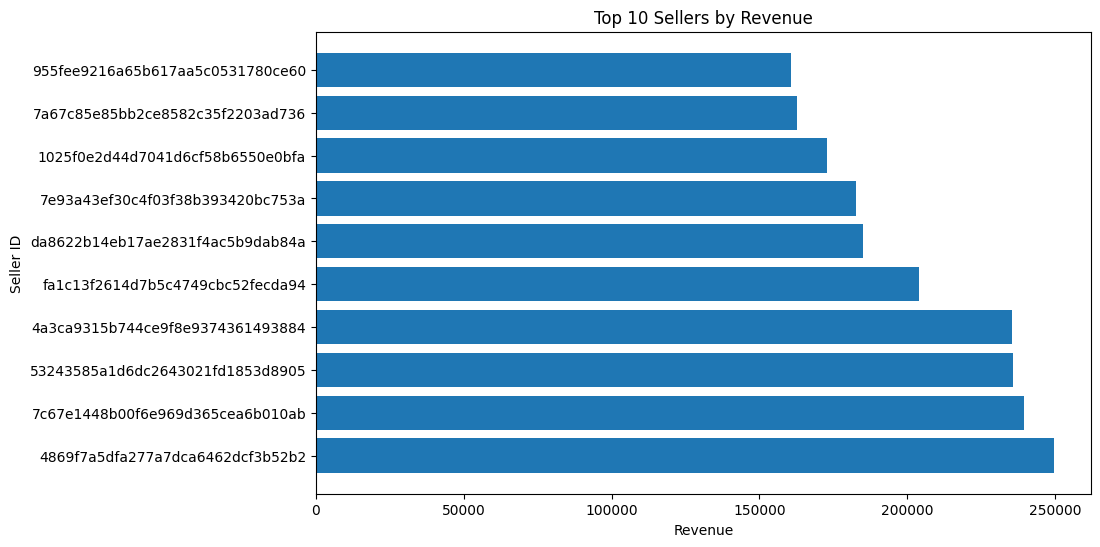

In [142]:
top_sellers = seller_revenue.sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
plt.barh(top_sellers.index, top_sellers.values)

plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Seller ID")

plt.show()

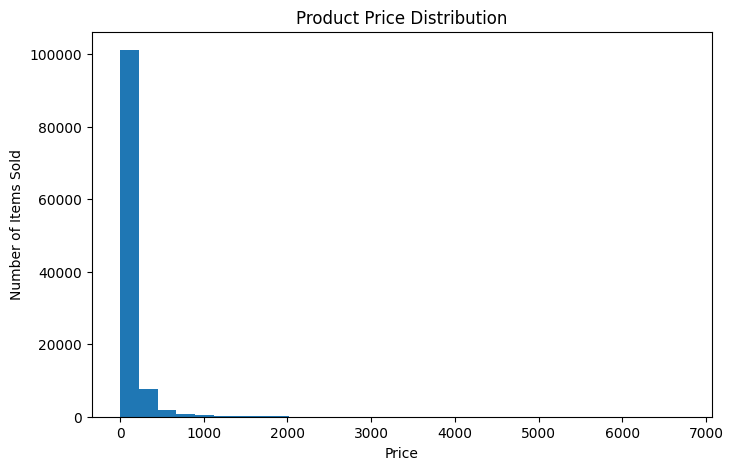

In [143]:
plt.figure(figsize=(8,5))

plt.hist(order_items["price"], bins=30)

plt.title("Product Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Items Sold")

plt.show()

The price distribution is right-skewed, indicating that most products are priced in the lower range, while a small number of high-priced products exist.

In [ ]:
order_revenue = order_items.groupby("order_id")["total_value"].sum()

order_revenue.head()


np.float64(160.57763809214924)

In [147]:
order_revenue.mean()

np.float64(160.57763809214924)

In [148]:
item_per_order = order_items.groupby("order_id")["order_item_id"].count()
item_per_order.describe()

count    98666.000000
mean         1.141731
std          0.538452
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         21.000000
Name: order_item_id, dtype: float64

In [150]:
products = pd.read_csv("../data/archive/olist_products_dataset.csv")
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [157]:
products.shape
products.columns
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB


In [159]:
products["product_category_name"].isna().sum()

np.int64(610)

In [167]:
order_items_product = order_items.merge(
    products[["product_id","product_category_name"]],
    on = "product_id",
    how = "left"
)

order_items_product.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_value,product_category_name
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,72.19,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,259.83,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,216.87,moveis_decoracao
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,25.78,perfumaria
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,218.04,ferramentas_jardim


In [168]:
order_items_product.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   order_id               112650 non-null  str           
 1   order_item_id          112650 non-null  int64         
 2   product_id             112650 non-null  str           
 3   seller_id              112650 non-null  str           
 4   shipping_limit_date    112650 non-null  datetime64[us]
 5   price                  112650 non-null  float64       
 6   freight_value          112650 non-null  float64       
 7   total_value            112650 non-null  float64       
 8   product_category_name  111047 non-null  str           
dtypes: datetime64[us](1), float64(3), int64(1), str(4)
memory usage: 7.7 MB


In [171]:
order_items_product = order_items_product.dropna(subset=["product_category_name"])

In [172]:
order_items_product["product_category_name"].isna().sum()

np.int64(0)

In [177]:
category_translation = pd.read_csv("../data/archive/product_category_name_translation.csv")

category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [180]:
order_items_products = order_items_product.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

order_items_products.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'total_value',
       'product_category_name', 'product_category_name_english'],
      dtype='str')

In [181]:
category_revenue = order_items_products.groupby(
    "product_category_name_english"
)["total_value"].sum()

category_revenue.sort_values(ascending=False).head(10)

product_category_name_english
health_beauty            1441248.07
watches_gifts            1305541.61
bed_bath_table           1241681.72
sports_leisure           1156656.48
computers_accessories    1059272.40
furniture_decor           902511.79
housewares                778397.77
cool_stuff                719329.95
auto                      685384.32
garden_tools              584219.21
Name: total_value, dtype: float64

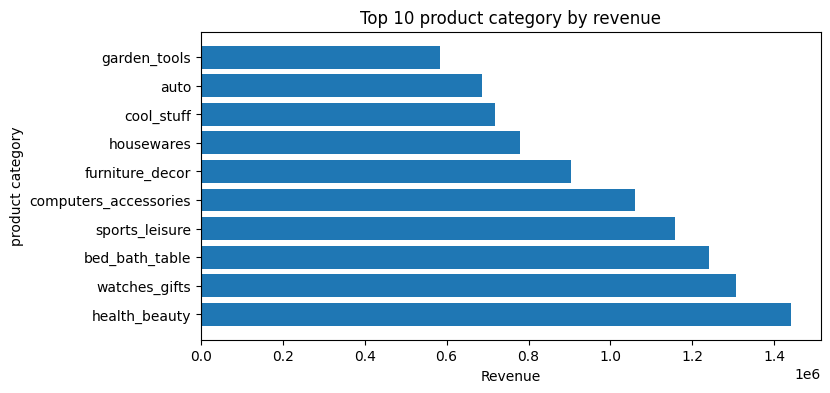

In [185]:
top_categories = category_revenue.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,4))

plt.barh(top_categories.index, top_categories.values)
plt.title("Top 10 product category by revenue")
plt.xlabel("Revenue")
plt.ylabel("product category")

plt.show()

In [186]:
category_sales = order_items_products.groupby(
    "product_category_name_english"
)["order_item_id"].count()

category_sales.sort_values(ascending=False).head(10)

product_category_name_english
bed_bath_table           11115
health_beauty             9670
sports_leisure            8641
furniture_decor           8334
computers_accessories     7827
housewares                6964
watches_gifts             5991
telephony                 4545
garden_tools              4347
auto                      4235
Name: order_item_id, dtype: int64

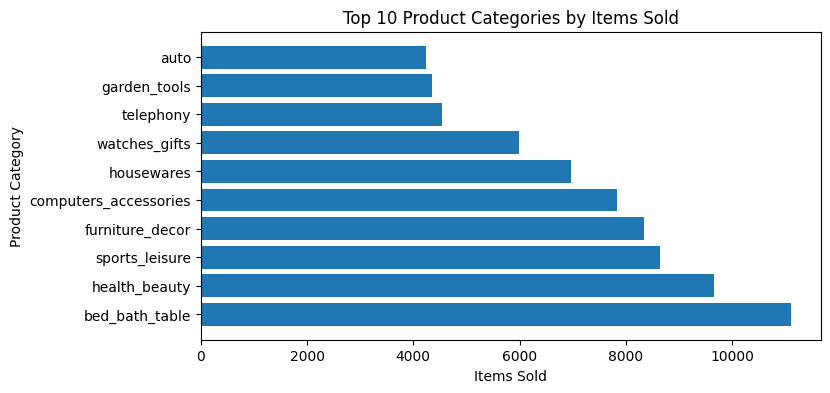

In [189]:
top_sales_categories = category_sales.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,4))
plt.barh(top_sales_categories.index, top_sales_categories.values)

plt.title("Top 10 Product Categories by Items Sold")
plt.xlabel("Items Sold")
plt.ylabel("Product Category")

plt.show()

In [190]:
customers = pd.read_csv("../data/archive/olist_customers_dataset.csv")

customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [191]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


In [192]:
customer_states = customers["customer_state"].value_counts()

customer_states.head(10)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

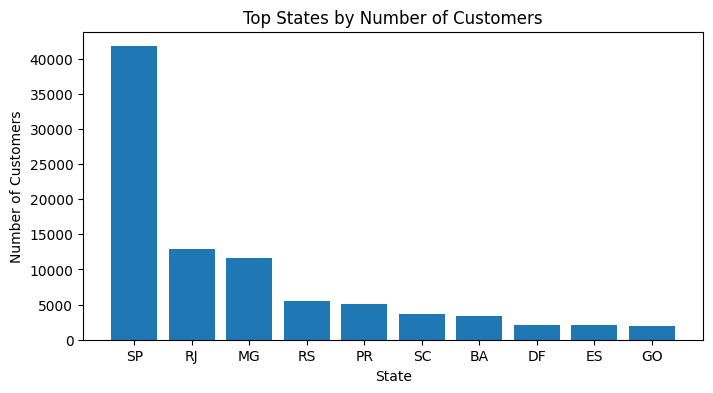

In [194]:
top_states = customer_states.head(10)

plt.figure(figsize=(8,4))
plt.bar(top_states.index, top_states.values)

plt.title("Top States by Number of Customers")
plt.xlabel("State")
plt.ylabel("Number of Customers")

plt.show()

In [197]:
payments = pd.read_csv("../data/archive/olist_order_payments_dataset.csv")
payments.head()


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [200]:
payments.shape
payments.columns
payments.info()


<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB


In [206]:
payments["payment_type_english"] = payments["payment_type"].replace({
    "credit_card": "Credit Card",
    "boleto": "Bank Slip (Boleto)",
    "voucher": "Voucher",
    "debit_card": "Debit Card",
    "not_defined": "Unknown"
})

In [207]:
payments["payment_type_english"].value_counts()

payment_type_english
Credit Card           76795
Bank Slip (Boleto)    19784
Voucher                5775
Debit Card             1529
Unknown                   3
Name: count, dtype: int64

In [208]:
installments = payments["payment_installments"].value_counts().sort_index()

installments

payment_installments
0         2
1     52546
2     12413
3     10461
4      7098
5      5239
6      3920
7      1626
8      4268
9       644
10     5328
11       23
12      133
13       16
14       15
15       74
16        5
17        8
18       27
20       17
21        3
22        1
23        1
24       18
Name: count, dtype: int64

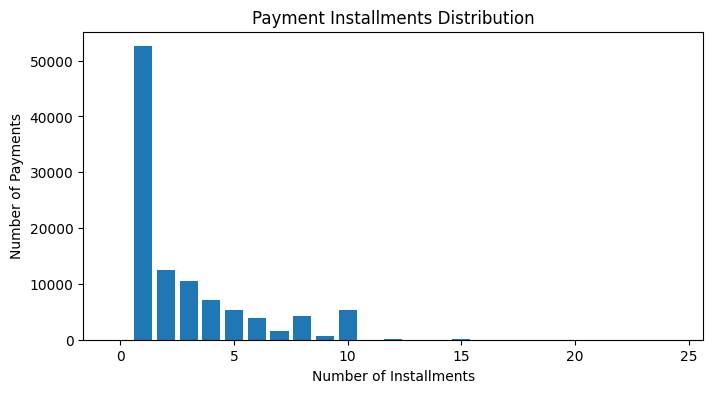

In [210]:
plt.figure(figsize=(8,4))

plt.bar(installments.index, installments.values)

plt.title("Payment Installments Distribution")
plt.xlabel("Number of Installments")
plt.ylabel("Number of Payments")

plt.show()

In [215]:
review = pd.read_csv("../data/archive/olist_order_reviews_dataset.csv")
review.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [216]:
review.shape
review.columns
review.info()

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.3 MB


In [217]:
rating_counts = review["review_score"].value_counts().sort_index()

rating_counts

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

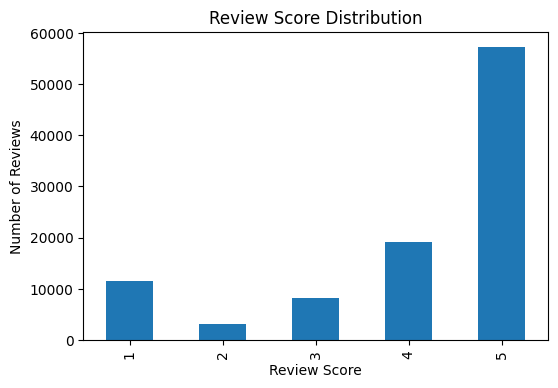

In [220]:
review["review_score"].value_counts().sort_index().plot(kind="bar", figsize=(6,4))

plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")

plt.show()

In [222]:
review_orders = review.merge(orders, on="order_id")

review_orders.groupby("review_score")["delivery_time"].mean()

review_score
1   21 days 07:28:26.611967
2   16 days 15:51:14.100306
3   14 days 06:17:13.556016
4   12 days 07:29:47.568125
5   10 days 16:31:35.505432
Name: delivery_time, dtype: timedelta64[us]

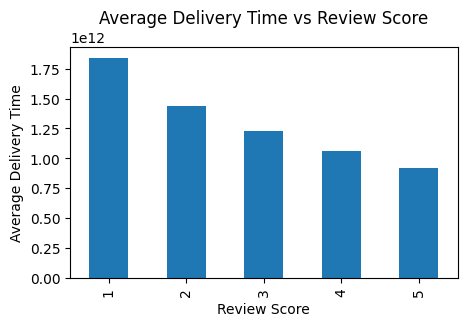

In [224]:
review_orders.groupby("review_score")["delivery_time"].mean().plot(kind="bar", figsize=(5,3))

plt.title("Average Delivery Time vs Review Score")
plt.xlabel("Review Score")
plt.ylabel("Average Delivery Time")

plt.show()

In [226]:
review_products = review.merge(order_items, on="order_id")
review_products = review_products.merge(products, on="product_id")

review_products.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,order_item_id,product_id,seller_id,...,freight_value,total_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59,1,fd25ab760bfbba13c198fa3b4f1a0cd3,6d803cb79cc31c41c4c789a75933b3c7,...,13.63,198.63,esporte_lazer,42.0,858.0,1.0,1300.0,30.0,30.0,35.0
1,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59,2,fd25ab760bfbba13c198fa3b4f1a0cd3,6d803cb79cc31c41c4c789a75933b3c7,...,13.63,198.63,esporte_lazer,42.0,858.0,1.0,1300.0,30.0,30.0,35.0
2,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13,1,be0dbdc3d67d55727a65d4cd696ca73c,8e6d7754bc7e0f22c96d255ebda59eba,...,8.30,88.09,informatica_acessorios,47.0,493.0,1.0,245.0,19.0,14.0,14.0
3,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24,1,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,...,45.12,194.12,informatica_acessorios,59.0,1893.0,1.0,6550.0,20.0,20.0,20.0
4,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06,1,52c80cedd4e90108bf4fa6a206ef6b03,a1043bafd471dff536d0c462352beb48,...,42.85,222.84,ferramentas_jardim,33.0,2188.0,2.0,7650.0,20.0,20.0,20.0


In [227]:
category_reviews = review_products.groupby("product_category_name")["review_score"].mean()

category_reviews.sort_values().head(10)

product_category_name
seguros_e_servicos                               2.500000
fraldas_higiene                                  3.256410
portateis_cozinha_e_preparadores_de_alimentos    3.266667
pc_gamer                                         3.333333
moveis_escritorio                                3.493183
casa_conforto_2                                  3.629630
fashion_roupa_masculina                          3.641221
telefonia_fixa                                   3.683206
artigos_de_festas                                3.767442
fashion_roupa_feminina                           3.780000
Name: review_score, dtype: float64

In [228]:
category_reviews.sort_values(ascending=False).head(10)

product_category_name
cds_dvds_musicais                     4.642857
fashion_roupa_infanto_juvenil         4.500000
livros_interesse_geral                4.446266
construcao_ferramentas_ferramentas    4.444444
flores                                4.419355
livros_importados                     4.400000
livros_tecnicos                       4.368421
alimentos_bebidas                     4.315412
malas_acessorios                      4.315257
portateis_casa_forno_e_cafe           4.302632
Name: review_score, dtype: float64

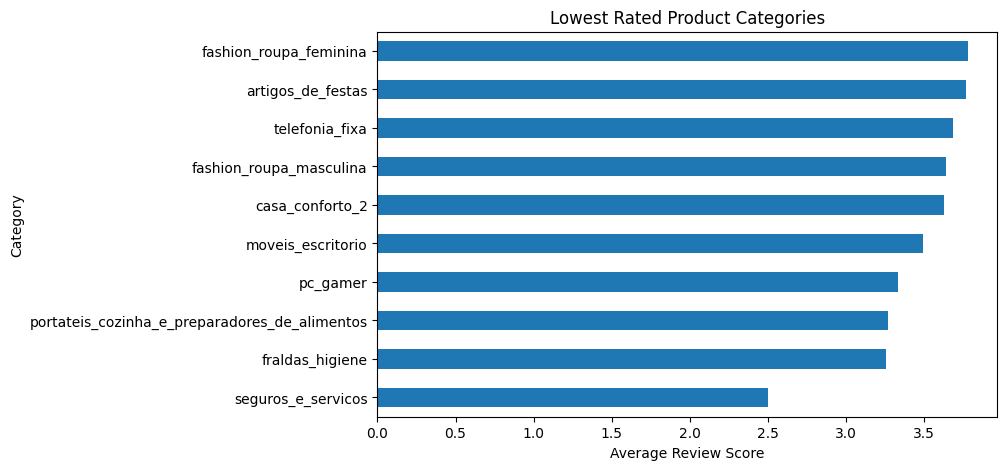

In [229]:
category_reviews.sort_values().head(10).plot(kind="barh", figsize=(8,5))

plt.title("Lowest Rated Product Categories")
plt.xlabel("Average Review Score")
plt.ylabel("Category")

plt.show()

In [230]:
category_reviews.sort_values().head(10)

product_category_name
seguros_e_servicos                               2.500000
fraldas_higiene                                  3.256410
portateis_cozinha_e_preparadores_de_alimentos    3.266667
pc_gamer                                         3.333333
moveis_escritorio                                3.493183
casa_conforto_2                                  3.629630
fashion_roupa_masculina                          3.641221
telefonia_fixa                                   3.683206
artigos_de_festas                                3.767442
fashion_roupa_feminina                           3.780000
Name: review_score, dtype: float64

In [231]:
seller_reviews = review_products.groupby("seller_id")["review_score"].mean()

seller_reviews.head()

seller_id
0015a82c2db000af6aaaf3ae2ecb0532    3.666667
001cca7ae9ae17fb1caed9dfb1094831    3.902542
001e6ad469a905060d959994f1b41e4f    1.000000
002100f778ceb8431b7a1020ff7ab48f    3.982143
003554e2dce176b5555353e4f3555ac8    5.000000
Name: review_score, dtype: float64

In [232]:
seller_reviews.sort_values().head(10)

seller_id
6d04126aba80df143fd038e711b8fd96    1.0
b6c6854d4d92a5f6f46be8869da3fa1a    1.0
34aefe746cd81b7f3b23253ea28bef39    1.0
b7ba853e9551f4558440881fd3e5c815    1.0
17adeba047385fb0c67d8e90b4296d21    1.0
e46bc031f2c5bae4ccb40bb90712e9b4    1.0
2a50b7ee5aebecc6fd0ff9784a4747d6    1.0
7e959205cebc10adefcb331f934238a4    1.0
0aa124728afc1131dff5655f4c6f487b    1.0
83d7070a0b9a8b4625fa8682b819fabb    1.0
Name: review_score, dtype: float64

In [233]:
seller_reviews.sort_values(ascending=False).head(10)

seller_id
1cd9e0cc1839d55516843def5600816d    5.0
9fbd5666d8618fa571c4230fafa09bd6    5.0
d3891911c2feae53c52fea2bd14054e5    5.0
702835e4b785b67a084280efca355756    5.0
a20d8058c866dbaeca014d2cd20ac62e    5.0
a213f1bd6458f4a158f3746cb2514559    5.0
1d953075c2f0dd990bacf27b83b330f1    5.0
404e1ba01358af4cd63f679b2c4d1fa1    5.0
a2b911e9ad40dc7d61c142a4683e2d85    5.0
70126eecc6aa1274392a1743866e9678    5.0
Name: review_score, dtype: float64

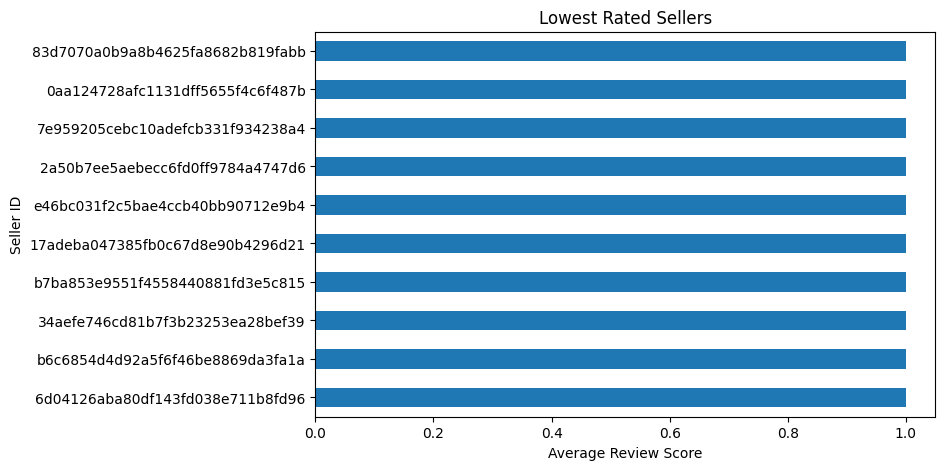

In [234]:
seller_reviews.sort_values().head(10).plot(kind="barh", figsize=(8,5))

plt.title("Lowest Rated Sellers")
plt.xlabel("Average Review Score")
plt.ylabel("Seller ID")

plt.show()

In [235]:
seller_reviews.sort_values().head(10)

seller_id
6d04126aba80df143fd038e711b8fd96    1.0
b6c6854d4d92a5f6f46be8869da3fa1a    1.0
34aefe746cd81b7f3b23253ea28bef39    1.0
b7ba853e9551f4558440881fd3e5c815    1.0
17adeba047385fb0c67d8e90b4296d21    1.0
e46bc031f2c5bae4ccb40bb90712e9b4    1.0
2a50b7ee5aebecc6fd0ff9784a4747d6    1.0
7e959205cebc10adefcb331f934238a4    1.0
0aa124728afc1131dff5655f4c6f487b    1.0
83d7070a0b9a8b4625fa8682b819fabb    1.0
Name: review_score, dtype: float64

In [237]:
review_payment = review.merge(payments, on="order_id")

review_payment.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,payment_sequential,payment_type,payment_installments,payment_value,payment_type_english
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59,1,credit_card,8,397.26,Credit Card
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13,1,credit_card,1,88.09,Credit Card
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24,1,credit_card,1,194.12,Credit Card
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06,1,credit_card,1,222.84,Credit Card
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53,1,credit_card,10,1333.25,Credit Card


In [238]:
payment_reviews = review_payment.groupby("payment_type")["review_score"].mean()

payment_reviews

payment_type
boleto         4.086631
credit_card    4.087637
debit_card     4.168084
not_defined    1.666667
voucher        4.003804
Name: review_score, dtype: float64

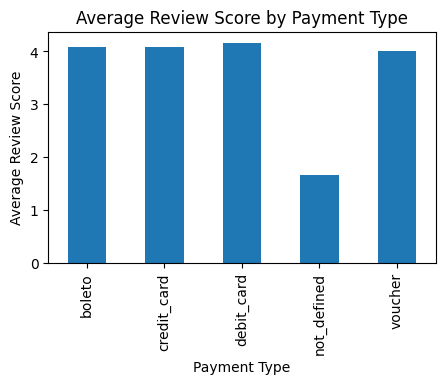

In [240]:
payment_reviews.plot(kind="bar", figsize=(5,3))

plt.title("Average Review Score by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Average Review Score")

plt.show()

In [241]:
orders.to_csv("orders_clean.csv", index=False)

In [242]:
order_items.to_csv("order_items_clean.csv", index=False)

In [243]:
customers.to_csv("customers_clean.csv", index=False)

In [244]:
products.to_csv("products_clean.csv", index=False)

In [247]:
review.to_csv("reviews_clean.csv", index=False)

In [248]:
payments.to_csv("payments_clean.csv", index=False)